# FCM Project: Study Performance Analysis

## Introduction

This project analyzes how study time, stress, sleep, and motivation affect student performance using Fuzzy Cognitive Maps (FCM).

In [27]:
from fcmpy import FcmSimulator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
concepts = ["Study", "Stress", "Sleep", "Motivation", "Grades"]

In [29]:
weight_matrix = pd.DataFrame([
    [0.0,  0.6, -0.4,  0.7,  0.8],
    [-0.5, 0.0, -0.6, -0.7, -0.8],
    [0.4, -0.5,  0.0,  0.5,  0.6],
    [0.6, -0.4,  0.5,  0.0,  0.7],
    [0.0,  0.0,  0.0,  0.0,  0.0]
], columns=concepts, index=concepts)

### Weight Matrix Explanation

- Study → Grades (0.8): Studying has a strong positive effect on grades
- Stress → Grades (-0.8): High stress negatively impacts performance
- Sleep → Study (0.4): Better sleep improves ability to study
- Motivation → Study (0.6): Motivation increases study effort

### Scenario 1: Balanced Student

This scenario represents a student with:
- Moderate study time
- Medium stress level
- Good sleep
- High motivation

We expect stable and good performance.

In [30]:
init_state1 = {
    "Study": 0.7,
    "Stress": 0.4,
    "Sleep": 0.7,
    "Motivation": 0.8,
    "Grades": 0.0
}

The values converged in the 8 state (e <= 0.001)


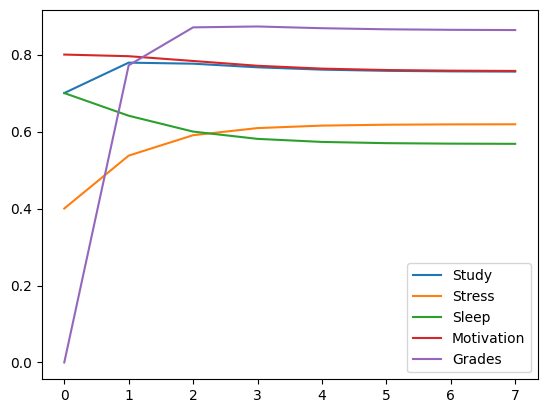

In [33]:
simulator = FcmSimulator()

res1 = simulator.simulate(
    initial_state=init_state1,
    weight_matrix=weight_matrix,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

res1.plot()
plt.show()

### Scenario 2: Stressed Student

This scenario represents a student with:
- Low study time
- High stress
- Poor sleep
- Low motivation

We expect lower performance because high stress and low sleep can negatively affect the student.

In [34]:
init_state2 = {
    "Study": 0.4,
    "Stress": 0.9,
    "Sleep": 0.3,
    "Motivation": 0.4,
    "Grades": 0.0
}

The values converged in the 9 state (e <= 0.001)


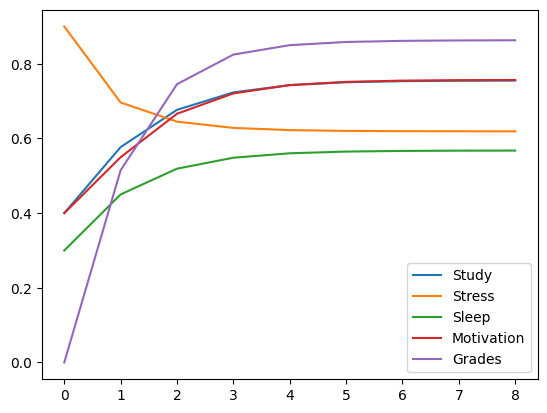

In [35]:
res2 = simulator.simulate(
    initial_state=init_state2,
    weight_matrix=weight_matrix,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

res2.plot()
plt.show()

### Scenario 3: High Performer

This scenario represents a student with:
- High study time
- Low stress
- Good sleep
- Very high motivation

We expect the best academic performance.

In [36]:
init_state3 = {
    "Study": 0.8,
    "Stress": 0.3,
    "Sleep": 0.6,
    "Motivation": 0.9,
    "Grades": 0.0
}

The values converged in the 8 state (e <= 0.001)


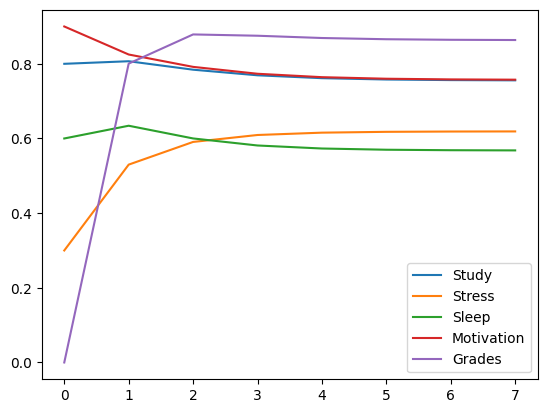

In [37]:
res3 = simulator.simulate(
    initial_state=init_state3,
    weight_matrix=weight_matrix,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

res3.plot()
plt.show()

In [38]:
intervention = {
    "Stress": -0.5,
    "Motivation": 0.5
}

In [ ]:
concepts = ["Study", "Stress", "Sleep", "Motivation", "Grades"]

### Scenario Comparison

Comparing the results:
- Scenario 1 leads to stable medium grades
- Scenario 2 shows lower performance due to high stress
- Scenario 3 achieves the highest grades due to strong study and motivation

### Analysis

The simulations show that:

- Stress has a strong negative influence on academic performance
- Study and motivation are the most important positive factors
- Sleep indirectly improves performance by reducing stress

From the scenarios, it is clear that reducing stress while maintaining high motivation leads to the best outcomes.
All scenarios converge to stable values, showing that the system is consistent.

This demonstrates how Fuzzy Cognitive Maps can model complex relationships and support decision-making in educational contexts.


### Conclusion

This project shows that FCM can simulate different student behaviors and predict performance outcomes. It can be extended to real-world educational systems for better decision support.